In [ ]:
import sys
import os

current_path = os.path.abspath(os.getcwd())

if current_path not in sys.path:
    sys.path.append(current_path)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time
from numba import jit

from  InitialDistribution import Moleculas
from  McPackage import MC

In [ ]:
Na   = 6.022e23              # 1/mol --> Avogadro number
T    = 700.0 + 273.15         # K
Rcte = 1.987/1000          # kcal/mol K
RT   = Rcte*T
MW   = 104.15
V    = 1.0e-16 # 1.0e-16


In [ ]:
t = 0.0
if T ==  (500.0 + 273.15):
    tend = 30  # seconds
    step = 1
elif T ==  (600.0 + 273.15):
    tend = 1.0  # seconds
    step = 0.001
else: # T ==  (700.0 + 273.15):
    tend = 0.04  # seconds
    step = 0.0001
time_interval = np.arange(t, tend+step, step)


In [ ]:
p_polymer = 1000/(0.9219+5.576e-4*(T-273.15) + 1.0648E-7*(T-273.15)**2) # DENSITY POLYMER (FUNCION OF TEMPERATURE)

p = 0.998  # Extent of reaction
DP = 6000
x = np.linspace(0,DP,num=DP)  # Degree of polymerization
wx = x*((1-p)**2)*p**(x-1)      # Weight fraction
print("Soma wx", np.sum(wx))
Mn_Flory = MW/(1-p)          # g/mol
Mw_Flory = (1+p)*MW/(1-p)    # g/mol
print("Mn Flory:", Mn_Flory)
print("Mw Flory:", Mw_Flory)


print (" ")
print("Volume: ", V, " L")
print(" ")

Soma wx 0.9997544256607285
Mn Flory: 52074.999999999956
Mw Flory: 104045.8499999999
 
Volume:  1e-16  L
 


In [ ]:
D,Dplotar,P0,Styrene_t0,X,R,Mn0,Mw0,Vsample,xPlotar,wx_PS = Moleculas(wx, Na, MW, p_polymer, V) # X, R, D


Area PS original: 0.9979717612541563


In [6]:

#print("Initializing kMC")
print('\033[1m' + 'Initializing kMC' + '\033[0m')

print("tend", tend)

startime = time.time()
X,P,D2,D1_Unsat,D2_Unsat,Styrene,Dimer,Trimer,DeadPolymer,Rs,Rp,Rm,Mn_MC,Mw_MC,tfim,erro,SumBonds = MC(V, Na, RT, T, 0.0,tend,time_interval,X,R,D)
endtime = time.time() - startime
print(" ")
print("tCPU:", endtime/60, " min")

Initializing kMC
tend 0.04
kdm: 0.1504748889348841
kf0 1.3421673479373026
V: 1e-16
Na: 6.022e+23
R initial: R[23] =  567583841.4973449
kdmMC 2.489624100564355e-16
SumBonds[0] 422886045.0
time: 0.0 0.48 .X[12] Sty 0 X[26] 1514460 0.0 . sumCCbonds: 420869888.0
time: 0.0 0.9 .X[12] Sty 0 X[26] 3046312 0.0 . sumCCbonds: 419100617.0
time: 0.0 1.31 .X[12] Sty 0 X[26] 4584503 0.0 . sumCCbonds: 417337638.0
time: 0.0 1.73 .X[12] Sty 0 X[26] 6110972 0.0 . sumCCbonds: 415571805.0
time: 0.001 2.15 .X[12] Sty 0 X[26] 7647768 0.0 . sumCCbonds: 413801157.0
time: 0.001 2.57 .X[12] Sty 0 X[26] 9179822 0.0 . sumCCbonds: 412000394.0
time: 0.001 2.99 .X[12] Sty 0 X[26] 10716770 0.0 . sumCCbonds: 410239607.0
time: 0.001 3.42 .X[12] Sty 0 X[26] 12263510 0.0 . sumCCbonds: 408427668.0
time: 0.001 3.85 .X[12] Sty 0 X[26] 13807421 0.0 . sumCCbonds: 406595338.0
time: 0.001 4.28 .X[12] Sty 0 X[26] 15357299 0.0 . sumCCbonds: 404766645.0
time: 0.001 4.72 .X[12] Sty 0 X[26] 16902448 0.0 . sumCCbonds: 402924484.0
tim

time: 0.011 49.32 .X[12] Sty 0 X[26] 164708867 0.0 . sumCCbonds: 214327399.0
time: 0.011 49.73 .X[12] Sty 0 X[26] 166034866 0.0 . sumCCbonds: 212565131.0
time: 0.011 50.15 .X[12] Sty 0 X[26] 167356135 0.0 . sumCCbonds: 210815502.0
time: 0.011 50.57 .X[12] Sty 0 X[26] 168680805 0.0 . sumCCbonds: 209051930.0
time: 0.011 50.98 .X[12] Sty 0 X[26] 170006280 0.0 . sumCCbonds: 207292278.0
time: 0.012 51.4 .X[12] Sty 0 X[26] 171321047 0.0 . sumCCbonds: 205539616.0
time: 0.012 51.81 .X[12] Sty 0 X[26] 172626186 0.0 . sumCCbonds: 203799383.0
time: 0.012 52.22 .X[12] Sty 0 X[26] 173928462 0.0 . sumCCbonds: 202065983.0
time: 0.012 52.63 .X[12] Sty 0 X[26] 175227951 0.0 . sumCCbonds: 200332210.0
time: 0.012 53.04 .X[12] Sty 0 X[26] 176522845 0.0 . sumCCbonds: 198601349.0
time: 0.012 53.44 .X[12] Sty 0 X[26] 177817759 0.0 . sumCCbonds: 196877507.0
time: 0.012 53.85 .X[12] Sty 0 X[26] 179107561 0.0 . sumCCbonds: 195149652.0
time: 0.012 54.26 .X[12] Sty 0 X[26] 180384464 0.0 . sumCCbonds: 193447312.0


time: 0.022 86.15 .X[12] Sty 0 X[26] 279810608 0.0 . sumCCbonds: 58552074.0
time: 0.022 86.39 .X[12] Sty 0 X[26] 280539220 0.0 . sumCCbonds: 57547329.0
time: 0.022 86.63 .X[12] Sty 0 X[26] 281259376 0.0 . sumCCbonds: 56553872.0
time: 0.022 86.86 .X[12] Sty 0 X[26] 281969840 0.0 . sumCCbonds: 55573063.0
time: 0.022 87.09 .X[12] Sty 0 X[26] 282679648 0.0 . sumCCbonds: 54592441.0
time: 0.023 87.32 .X[12] Sty 0 X[26] 283375355 0.0 . sumCCbonds: 53631816.0
time: 0.023 87.54 .X[12] Sty 0 X[26] 284067975 0.0 . sumCCbonds: 52674807.0
time: 0.023 87.77 .X[12] Sty 0 X[26] 284753240 0.0 . sumCCbonds: 51728611.0
time: 0.023 87.99 .X[12] Sty 0 X[26] 285431813 0.0 . sumCCbonds: 50787541.0
time: 0.023 88.21 .X[12] Sty 0 X[26] 286111555 0.0 . sumCCbonds: 49848421.0
time: 0.023 88.43 .X[12] Sty 0 X[26] 286777545 0.0 . sumCCbonds: 48924929.0
time: 0.023 88.65 .X[12] Sty 0 X[26] 287441442 0.0 . sumCCbonds: 48006359.0
time: 0.023 88.86 .X[12] Sty 0 X[26] 288092262 0.0 . sumCCbonds: 47107479.0
time: 0.023 

time: 0.034 99.8 .X[12] Sty 0 X[26] 321157811 0.0 . sumCCbonds: 828308.0
time: 0.034 99.82 .X[12] Sty 0 X[26] 321192659 0.0 . sumCCbonds: 777862.0
time: 0.034 99.83 .X[12] Sty 0 X[26] 321224606 0.0 . sumCCbonds: 731263.0
time: 0.034 99.84 .X[12] Sty 0 X[26] 321254703 0.0 . sumCCbonds: 687583.0
time: 0.034 99.85 .X[12] Sty 0 X[26] 321283316 0.0 . sumCCbonds: 646019.0
time: 0.034 99.86 .X[12] Sty 0 X[26] 321309022 0.0 . sumCCbonds: 608368.0
time: 0.034 99.87 .X[12] Sty 0 X[26] 321334706 0.0 . sumCCbonds: 570657.0
time: 0.034 99.87 .X[12] Sty 0 X[26] 321359166 0.0 . sumCCbonds: 535557.0
time: 0.034 99.88 .X[12] Sty 0 X[26] 321381442 0.0 . sumCCbonds: 503019.0
time: 0.035 99.89 .X[12] Sty 0 X[26] 321401862 0.0 . sumCCbonds: 473616.0
time: 0.035 99.89 .X[12] Sty 0 X[26] 321421473 0.0 . sumCCbonds: 444957.0
time: 0.035 99.9 .X[12] Sty 0 X[26] 321440082 0.0 . sumCCbonds: 417710.0
time: 0.035 99.91 .X[12] Sty 0 X[26] 321457158 0.0 . sumCCbonds: 392535.0
time: 0.035 99.91 .X[12] Sty 0 X[26] 321

In [7]:
print("CONVERSION-WITHOUT-CONSIDERED-POLYMER (%)")
print(" ")
print("Polymer:", np.round((SumBonds[0]-SumBonds[-1])*100/SumBonds[0],2))           # "Polymer:", np.round((X[0]+X[1]+X[2])*100/np.sum(X[3:]),2))
print(" ")
print("Mol %")
print(" ")
products = np.sum(X[12:17]) + np.sum(X[18:20]) + X[21] + np.sum(X[24:])
print("Monomer:", np.round(X[12]*100/products,2), X[26]*100/products)
print("alpha-Methylstyrene:", np.round(X[13]*100/products,2), X[27]*100/products)
print("DPP:", np.round(X[15]*100/products,2), X[2]*100/products)
print("Dimer:", np.round(X[14]*100/products,2), X[29]*100/products)
print("Trimer:", np.round(X[16]*100/products,2), X[30]*100/products)
print("Toluene:", np.round(X[19]*100/products, 2), X[24]*100/products)
print("Ethylbenzene:", X[18]*100/products, X[25]*100/products)
print(" ")

CONVERSION-WITHOUT-CONSIDERED-POLYMER (%)
 
Polymer: 100.0
 
Mol %
 
Monomer: 0.0 85.60357704171466
alpha-Methylstyrene: 0.0 1.6689712784320636
DPP: 0.0 1.8626279032654735e-06
Dimer: 0.0 2.205678993887595
Trimer: 0.0 3.9724363746131925
Toluene: 0.0 4.080299559953094
Ethylbenzene: 0.0 0.10121972378835377
 


In [8]:
axis_x_1 = [7, 8, 9, 15, 16, 24]
labels = ['Toluene', 'Styrene', 'aMS', 'DPP', 'Dimer', 'Trimer']

print("ethylbenzene:", (X[18] + X[17])*100/np.sum(X[3:]))           # Ethylbenzene = C8H10
print("ethylbenzene:", (X[25])*100/np.sum(X[24:]))                  # Ethylbenzene = C8H10

ethylbenzene: 5.320637441096886e-07
ethylbenzene: 0.10121972378835377


In [ ]:
C_Distribution     = np.zeros(6)
C_Distribution[0]  += X[24]           # X[19] + X[24] # X[19] + X[10]   # Toluene = C7H8
C_Distribution[1]  += X[26]           # X[12] + D2[1]   # Monomer = Styrene = C8H8
C_Distribution[2]  += X[27]           # X[27]  + X[13] # X[9]  + X[13]    # Alpha-methylstyrene
C_Distribution[3]  += X[28]           # X[14] + D2[2]   # Dimer   = C16H16
C_Distribution[4]  += X[29]           # X[15] # + X[11]   # DPP     = C16H16
C_Distribution[5]  += X[30]           # X[16] + D2[3]   # Trimer  = C24H26

print("C_Distribution", C_Distribution)
# C_Distribution[1]  += X[25] # X[18]        # + Ethylbenzene = C8H10

C_Distribution [1.53343010e+07 3.21709472e+08 6.27221300e+06 8.89856700e+06
 8.28923100e+06 1.49289370e+07]


In [ ]:
mass_toluene      = X[24]*92.14/Na     # moleculas * mol/moleculas * g/mol = g
mass_styrene      = X[26]*104.15/Na
mass_aMs          = X[27]*118.18/Na
mass_dimer        = X[28]*210.32/Na
mass_DPP          = X[29]*210.32/Na
mass_trimer       = X[30]*312.46/Na
mass_ethylbenzene = X[25]*106.17/Na
mass_products     = mass_toluene + mass_styrene + mass_aMs + mass_dimer + mass_DPP + mass_trimer + mass_ethylbenzene

print("mass_products", mass_products)
print("toluene:",mass_toluene*100/mass_products)
print("Monomer:",mass_styrene*100/mass_products)
print("aMS:",mass_aMs*100/mass_products)
print("Dimer:",mass_dimer*100/mass_products)
print("DPP:",mass_DPP*100/mass_products)
print("Trimer:",mass_trimer*100/mass_products)

mass_products 7.303257093183328e-14
toluene: 3.212586658237088
Monomer: 76.18435268388954
aMS: 1.6854172849496019
Dimer: 4.25542859405924
DPP: 3.9640349530617986
Trimer: 10.6063504652352


In [ ]:
C_Distribution_Percentage = np.zeros(6)
C_Distribution_Percentage[0] = C_Distribution[0]*100/np.sum(X[24:]) # Toluene = C7H8 C_Distribution[0]*100/np.sum(X[3:])
C_Distribution_Percentage[1] = C_Distribution[1]*100/np.sum(X[24:]) # Monomer
C_Distribution_Percentage[2] = C_Distribution[2]*100/np.sum(X[24:]) # aMS
C_Distribution_Percentage[3] = C_Distribution[3]*100/np.sum(X[24:]) # Dimer
C_Distribution_Percentage[4] = C_Distribution[4]*100/np.sum(X[24:]) # DPP
C_Distribution_Percentage[5] = C_Distribution[5]*100/np.sum(X[24:]) # Trimer

C_Distribution_Percentage[0] *= 92.14
C_Distribution_Percentage[1] *= 104.15
C_Distribution_Percentage[2] *= 118.18
C_Distribution_Percentage[3] *= 210.32
C_Distribution_Percentage[4] *= 210.32
C_Distribution_Percentage[5] *= 312.46

C_Distribution_Percentage = C_Distribution_Percentage*100/np.sum(C_Distribution_Percentage)
C_Distribution_Percentage = np.round(C_Distribution_Percentage, 2)

In [ ]:
C_Distribution_experimental = np.zeros(6)
C_Distribution_experimental_error = np.zeros(6)

if T == (500.0 + 273.15):
    C_Distribution_experimental[1] = 75.7 # Monomer
    C_Distribution_experimental[4] = 6.1 # Dimer
    C_Distribution_experimental[5] = 12.2  # Trimer
    C_Distribution_experimental[0] = 0.8 # Toluene = C7H8
    C_Distribution_experimental[2] = 0.2 # aMS
    C_Distribution_experimental[3] += 7.4 # DPP

    C_Distribution_experimental_error[1] = 6.1 # Monomer
    C_Distribution_experimental_error[4] = 1.2 # Dimer
    C_Distribution_experimental_error[5] = 4.0  # Trimer
    C_Distribution_experimental_error[0] = 0.8*0.05 # Toluene = C7H8
    C_Distribution_experimental_error[2] = 0.2*0.05 # aMS
    C_Distribution_experimental_error[3] += 6.1 # DPP

elif T == (600.0 + 273.15):
    C_Distribution_experimental[1] = 76.4 # Monomer
    C_Distribution_experimental[4] = 4.2 # Dimer
    C_Distribution_experimental[5] = 8.5  # Trimer
    C_Distribution_experimental[0] = 0.75 # Toluene = C7H8
    C_Distribution_experimental[2] = 0.25 # aMS
    C_Distribution_experimental[3] += 0.55 # DPP

    C_Distribution_experimental_error[1] = 3.7 # Monomer
    C_Distribution_experimental_error[4] = 1.5 # Dimer
    C_Distribution_experimental_error[5] = 3.0  # Trimer
    C_Distribution_experimental_error[0] = 0.75*0.05 # Toluene = C7H8
    C_Distribution_experimental_error[2] = 0.25*0.05 # aMS
    C_Distribution_experimental_error[3] += 0.1 # DPP

else:
    C_Distribution_experimental[1] = 77.2 # Monomer
    C_Distribution_experimental[4] = 3.4  # Dimer
    C_Distribution_experimental[5] = 5.2  # Trimer
    C_Distribution_experimental[0] = 0.7  # Toluene = C7H8
    C_Distribution_experimental[2] = 0.4  # aMS
    C_Distribution_experimental[3] += 1.4 # DPP

    C_Distribution_experimental_error[1] = 1.1      # Monomer
    C_Distribution_experimental_error[4] = 3.4*0.05 # Dimer
    C_Distribution_experimental_error[5] = 5.2*0.5 # 0.3      # Trimer
    C_Distribution_experimental_error[0] = 0.7*0.05 # Toluene = C7H8
    C_Distribution_experimental_error[2] = 0.1      # aMS
    C_Distribution_experimental_error[3] = 0.3     # DPP


In [ ]:
C_Distribution_experimental_error[0] /= C_Distribution_experimental[0]
C_Distribution_experimental_error[1] /= C_Distribution_experimental[1]
C_Distribution_experimental_error[2] /= C_Distribution_experimental[2]
C_Distribution_experimental_error[3] /= C_Distribution_experimental[3]
C_Distribution_experimental_error[4] /= C_Distribution_experimental[4]
C_Distribution_experimental_error[5] /= C_Distribution_experimental[5]

In [14]:
C_Distribution_experimental[0] *= 92.14
C_Distribution_experimental[1] *= 104.15
C_Distribution_experimental[2] *= 118.18
C_Distribution_experimental[3] *= 210.32
C_Distribution_experimental[4] *= 210.32
C_Distribution_experimental[5] *= 312.46

C_Distribution_experimental = C_Distribution_experimental*100/np.sum(C_Distribution_experimental)
C_Distribution_experimental  = np.round(C_Distribution_experimental, 2)

In [ ]:
C_Distribution_experimental_error[0] *= C_Distribution_experimental[0]
C_Distribution_experimental_error[1] *= C_Distribution_experimental[1]
C_Distribution_experimental_error[2] *= C_Distribution_experimental[2]
C_Distribution_experimental_error[3] *= C_Distribution_experimental[3]
C_Distribution_experimental_error[4] *= C_Distribution_experimental[4]
C_Distribution_experimental_error[5] *= C_Distribution_experimental[5]

In [23]:
C_Distribution_Percentage = np.round(C_Distribution_Percentage, 1)
C_Distribution_experimental = np.round(C_Distribution_experimental, 1)


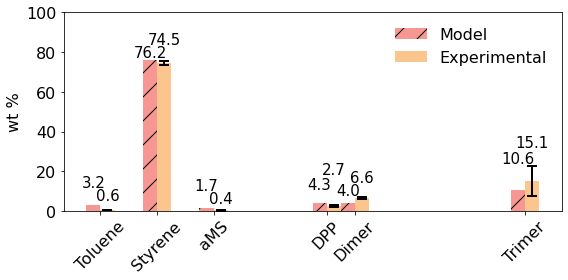

In [ ]:
axis_x_1 = [7, 9, 11, 15, 16, 22]    # [7, 8, 9, 16, 24]
fig, ax = plt.subplots(figsize=(8,4))
width = 0.5
axis_x_2 = [p + width for p in axis_x_1]
axis_x_3 = [p + 0.5*width for p in axis_x_1]


plt.bar(axis_x_1, C_Distribution_Percentage, width, alpha=0.5, color='#EE3224', hatch='/', label='Model')
plt.bar(axis_x_2, C_Distribution_experimental, width, alpha=0.5, yerr=C_Distribution_experimental_error, error_kw=dict(ecolor='black', lw=2, capsize=5, capthick=2), color='#F78F1E', label='Experimental')
## plt.bar(axis_x_2[-2], 7.4, width, alpha=0.5, yerr=6.1, color='#FFC222', label='DPP') # experimental

# plt.bar(axis_x_2[-3], 6.1, width, alpha=1, yerr=1.2, error_kw=dict(ecolor='grey', lw=2, capsize=5, capthick=2), color='crimson', label='Dimer Exp.')   # experimental
# plt.bar(axis_x_1[-3], (X[14] + D2[2])*100/np.sum(X[3:]), width, alpha=1, color='crimson', label='Dimer Model')   # experimental


ax.set_ylabel('wt %', fontsize=16)
ax.set_xticks(axis_x_3)

ax.set_xticklabels(labels)
ax.annotate('{}'.format(C_Distribution_experimental[0]), xy=(axis_x_2[0], np.maximum(C_Distribution_experimental[0], C_Distribution_Percentage[0])), xytext=(0, 2), textcoords="offset points",  ha='center', va='bottom', fontsize=15)
ax.annotate('{}'.format(np.round(C_Distribution_Percentage[0],1)), xy=(axis_x_1[0], np.maximum(C_Distribution_experimental[0], C_Distribution_Percentage[0])), xytext=(0, 15), textcoords="offset points",  ha='center', va='bottom', fontsize=15)

ax.annotate('{}'.format(C_Distribution_experimental[2]), xy=(axis_x_2[2], np.maximum(C_Distribution_experimental[2], C_Distribution_Percentage[2])), xytext=(0, 2), textcoords="offset points",  ha='center', va='bottom', fontsize=15)
ax.annotate('{}'.format(np.round(C_Distribution_Percentage[2],1)), xy=(axis_x_1[2], np.maximum(C_Distribution_experimental[2], C_Distribution_Percentage[2])), xytext=(0, 15), textcoords="offset points",  ha='center', va='bottom', fontsize=15)

ax.annotate('{}'.format(C_Distribution_experimental[1]), xy=(axis_x_2[1], np.maximum(C_Distribution_experimental[1], C_Distribution_Percentage[1])), xytext=(0, 13), textcoords="offset points",  ha='center', va='bottom', fontsize=15)
ax.annotate('{}'.format(np.round(C_Distribution_Percentage[1],1)), xy=(axis_x_1[1], np.maximum(C_Distribution_experimental[1], C_Distribution_Percentage[1])), xytext=(0, 0), textcoords="offset points",  ha='center', va='bottom', fontsize=15)

ax.annotate('{}'.format(C_Distribution_experimental[3]), xy=(axis_x_2[3], np.maximum(C_Distribution_experimental[3], C_Distribution_Percentage[3])), xytext=(0, 25), textcoords="offset points",  ha='center', va='bottom', fontsize=15)
ax.annotate('{}'.format(np.round(C_Distribution_Percentage[3],1)), xy=(axis_x_1[3], np.maximum(C_Distribution_experimental[3], C_Distribution_Percentage[3])), xytext=(0, 10), textcoords="offset points",  ha='center', va='bottom', fontsize=15)
# ax.annotate('{}'.format("6.1 Dimer + 7.4 DPP"), xy=(axis_x_2[3], np.maximum(C_Distribution_experimental_500[3], C_Distribution_Percentage[3])), xytext=(0, 24), textcoords="offset points",  ha='center', va='bottom', fontsize=14)
# ax.annotate('{}'.format("3.8 Dimer + 3.1 DPP"), xy=(axis_x_1[3], np.maximum(C_Distribution_experimental_500[3], C_Distribution_Percentage[3])), xytext=(0, 2), textcoords="offset points",  ha='center', va='bottom', fontsize=14)

ax.annotate('{}'.format(C_Distribution_experimental[4]), xy=(axis_x_2[4], np.maximum(C_Distribution_experimental[4], C_Distribution_Percentage[4])), xytext=(0, 13), textcoords="offset points",  ha='center', va='bottom', fontsize=15)
ax.annotate('{}'.format(np.round(C_Distribution_Percentage[4],1)), xy=(axis_x_1[4], np.maximum(C_Distribution_experimental[4], C_Distribution_Percentage[4])), xytext=(0, 0), textcoords="offset points",  ha='center', va='bottom', fontsize=15)


ax.annotate('{}'.format(C_Distribution_experimental[5]), xy=(axis_x_2[5], np.maximum(C_Distribution_experimental[5], C_Distribution_Percentage[5])), xytext=(0, 31), textcoords="offset points",  ha='center', va='bottom', fontsize=15)
ax.annotate('{}'.format(np.round(C_Distribution_Percentage[5],1)), xy=(axis_x_1[5], np.maximum(C_Distribution_experimental[5], C_Distribution_Percentage[5])), xytext=(0, 15), textcoords="offset points",  ha='center', va='bottom', fontsize=15)


plt.xticks(fontsize=16, rotation=45)
plt.yticks(fontsize=16)


plt.ylim(0, 100)
plt.legend(frameon=False, fontsize=16)
plt.tight_layout()
plt.savefig("Fig9" + str(int(T-273.15)) + ".jpeg",format='jpeg',dpi = 1200,bbox_inches='tight')